In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import statsmodels.api as sm

sns.set_style("whitegrid")
sns.set_context("poster")
import warnings
warnings.filterwarnings("ignore")

In [2]:
column_names = [
    "id",                     # Kimlik (modelde kullanılmayacak)
    "platform_adi",           # Kategorik: fongogo, crowdfon, fonbulucu ...
    "kitle_fonlamasi_turu",   # Kategorik: ödül, bağış
    "kategori",               # Kategorik: teknoloji, kültür-sanat ...
    "fon_sekli",              # Kategorik: ya hep ya hiç / hepsi kalsın
    "proje_adi",              # Metin (modelde kullanılmayacak)
    "proje_sahibi",           # Metin (modelde kullanılmayacak)
    "proje_sahibi_cinsiyet",  # Kategorik: erkek, kadın, belirsiz
    "kac_proje_destekledi",   # Sayısal
    "kac_projeye_abone",      # Sayısal
    "kac_projenin_sahibi",    # Sayısal
    "kac_proje_takiminda",    # Sayısal
    "konum",                  # Kategorik: şehir (bolge ile aynı bilgiyi taşıdığı için çıkarılacak)
    "bolge",                  # Kategorik: marmara, ege ...
    "yil",                    # Sayısal
    "proje_baslama_tarihi",   # Tarih (modelde kullanılmayacak)
    "proje_bitis_tarihi",     # Tarih (modelde kullanılmayacak)
    "gun_sayisi",             # Sayısal: kampanya süresi
    "tanitim_videosu",        # Kategorik: var / yok
    "video_uzunlugu",         # Sayısal
    "gorsel_sayisi",          # Sayısal
    "sss",                    # Sayısal
    "guncellemeler",          # Sayısal
    "yorumlar",               # Sayısal
    "destekci_sayisi",        # Sayısal
    "odul_sayisi",            # Sayısal
    "ekip_kisi_sayisi",       # Sayısal
    "web_sitesi",             # Kategorik: var / yok
    "sosyal_medya",           # Kategorik: var / yok
    "sm_sayisi",              # Sayısal
    "sm_takipci",             # Sayısal
    "etiket_sayisi",          # Sayısal
    "icerik_kelime_sayisi",   # Sayısal
    "proje_aciklamasi",       # Metin (modelde kullanılmayacak)
    "hedef_miktari",          # Sayısal (TL)
    "toplanan_tutar",         # Hedef değişken (TL) - tahmin edeceğimiz değer
    "destek_orani",           # Metin/sayı: toplanan / hedef (%)
    "basari_durumu"           # Kategorik: başarılı / başarısız
]
df= pd.read_csv("/content/turkishCF.csv",sep=";",encoding="utf-8-sig",header=0,names=column_names)
df["Destek_Orani_Sayi"] = df["destek_orani"].astype(str).str.replace("%","").astype(float)
df.head(2)

,id,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,...,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,toplanan_tutar,destek_orani,basari_durumu,Destek_Orani_Sayi
0,1,fongogo,ödül,diğer,ya hep ya hiç,Gerçek Gizlidir Filmleri,Lob Ekibi,belirsiz,1,0,...,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,136%,başarılı,136.0
1,2,fongogo,ödül,diğer,ya hep ya hiç,Fongogo - Hayat Bulsun!,Fongogo Team,belirsiz,3,0,...,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,100%,başarılı,100.0


In [3]:
print("Veri Seti Boyutu:",df.shape)
df.info()

Veri Seti Boyutu: (1628, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1628 non-null   int64  
 1   platform_adi           1628 non-null   object 
 2   kitle_fonlamasi_turu   1628 non-null   object 
 3   kategori               1628 non-null   object 
 4   fon_sekli              1628 non-null   object 
 5   proje_adi              1628 non-null   object 
 6   proje_sahibi           1628 non-null   object 
 7   proje_sahibi_cinsiyet  1628 non-null   object 
 8   kac_proje_destekledi   1628 non-null   int64  
 9   kac_projeye_abone      1628 non-null   int64  
 10  kac_projenin_sahibi    1628 non-null   int64  
 11  kac_proje_takiminda    1628 non-null   int64  
 12  konum                  1628 non-null   object 
 13  bolge                  1627 non-null   object 
 14  yil                    1628

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1628.0,814.500000,470.107435,1.0,407.75,814.5,1221.25,1628.0
kac_proje_destekledi,1628.0,0.429361,2.225029,0.0,0.00,0.0,0.00,31.0
kac_projeye_abone,1628.0,0.000614,0.024784,0.0,0.00,0.0,0.00,1.0
kac_projenin_sahibi,1628.0,1.165848,0.710455,1.0,1.00,1.0,1.00,7.0
kac_proje_takiminda,1628.0,0.052826,0.244744,0.0,0.00,0.0,0.00,4.0
yil,1628.0,2018.042383,2.054583,2011.0,2017.00,2019.0,2020.00,2021.0
gun_sayisi,1628.0,52.004914,15.294526,0.0,45.00,60.0,60.00,118.0
video_uzunlugu,1628.0,67.668305,108.145452,0.0,0.00,46.0,98.25,1651.0
gorsel_sayisi,1628.0,5.036855,7.842166,0.0,1.00,3.0,7.00,221.0
sss,1628.0,0.203317,1.439136,0.0,0.00,0.0,0.00,30.0


In [6]:
df["platform_adi"].value_counts()

,count
platform_adi,
fongogo,1075
crowdfon,237
fonbulucu,235
arıkovanı,58
buluşum,13
ideanest,10


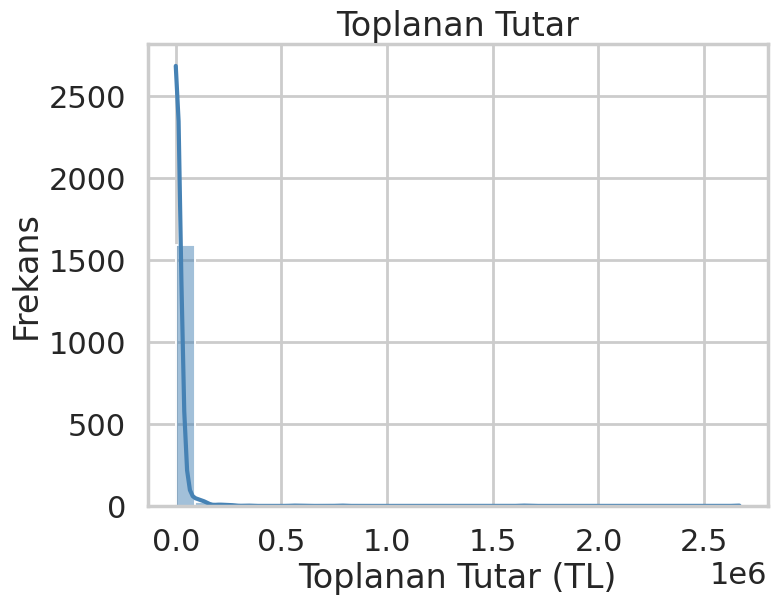

In [7]:
plt.figure(figsize=(8,6))
sns.histplot(df["toplanan_tutar"],bins=30,kde= True, color ="steelblue")

plt.title("Toplanan Tutar")
plt.xlabel("Toplanan Tutar (TL)")
plt.ylabel("Frekans")

plt.show()


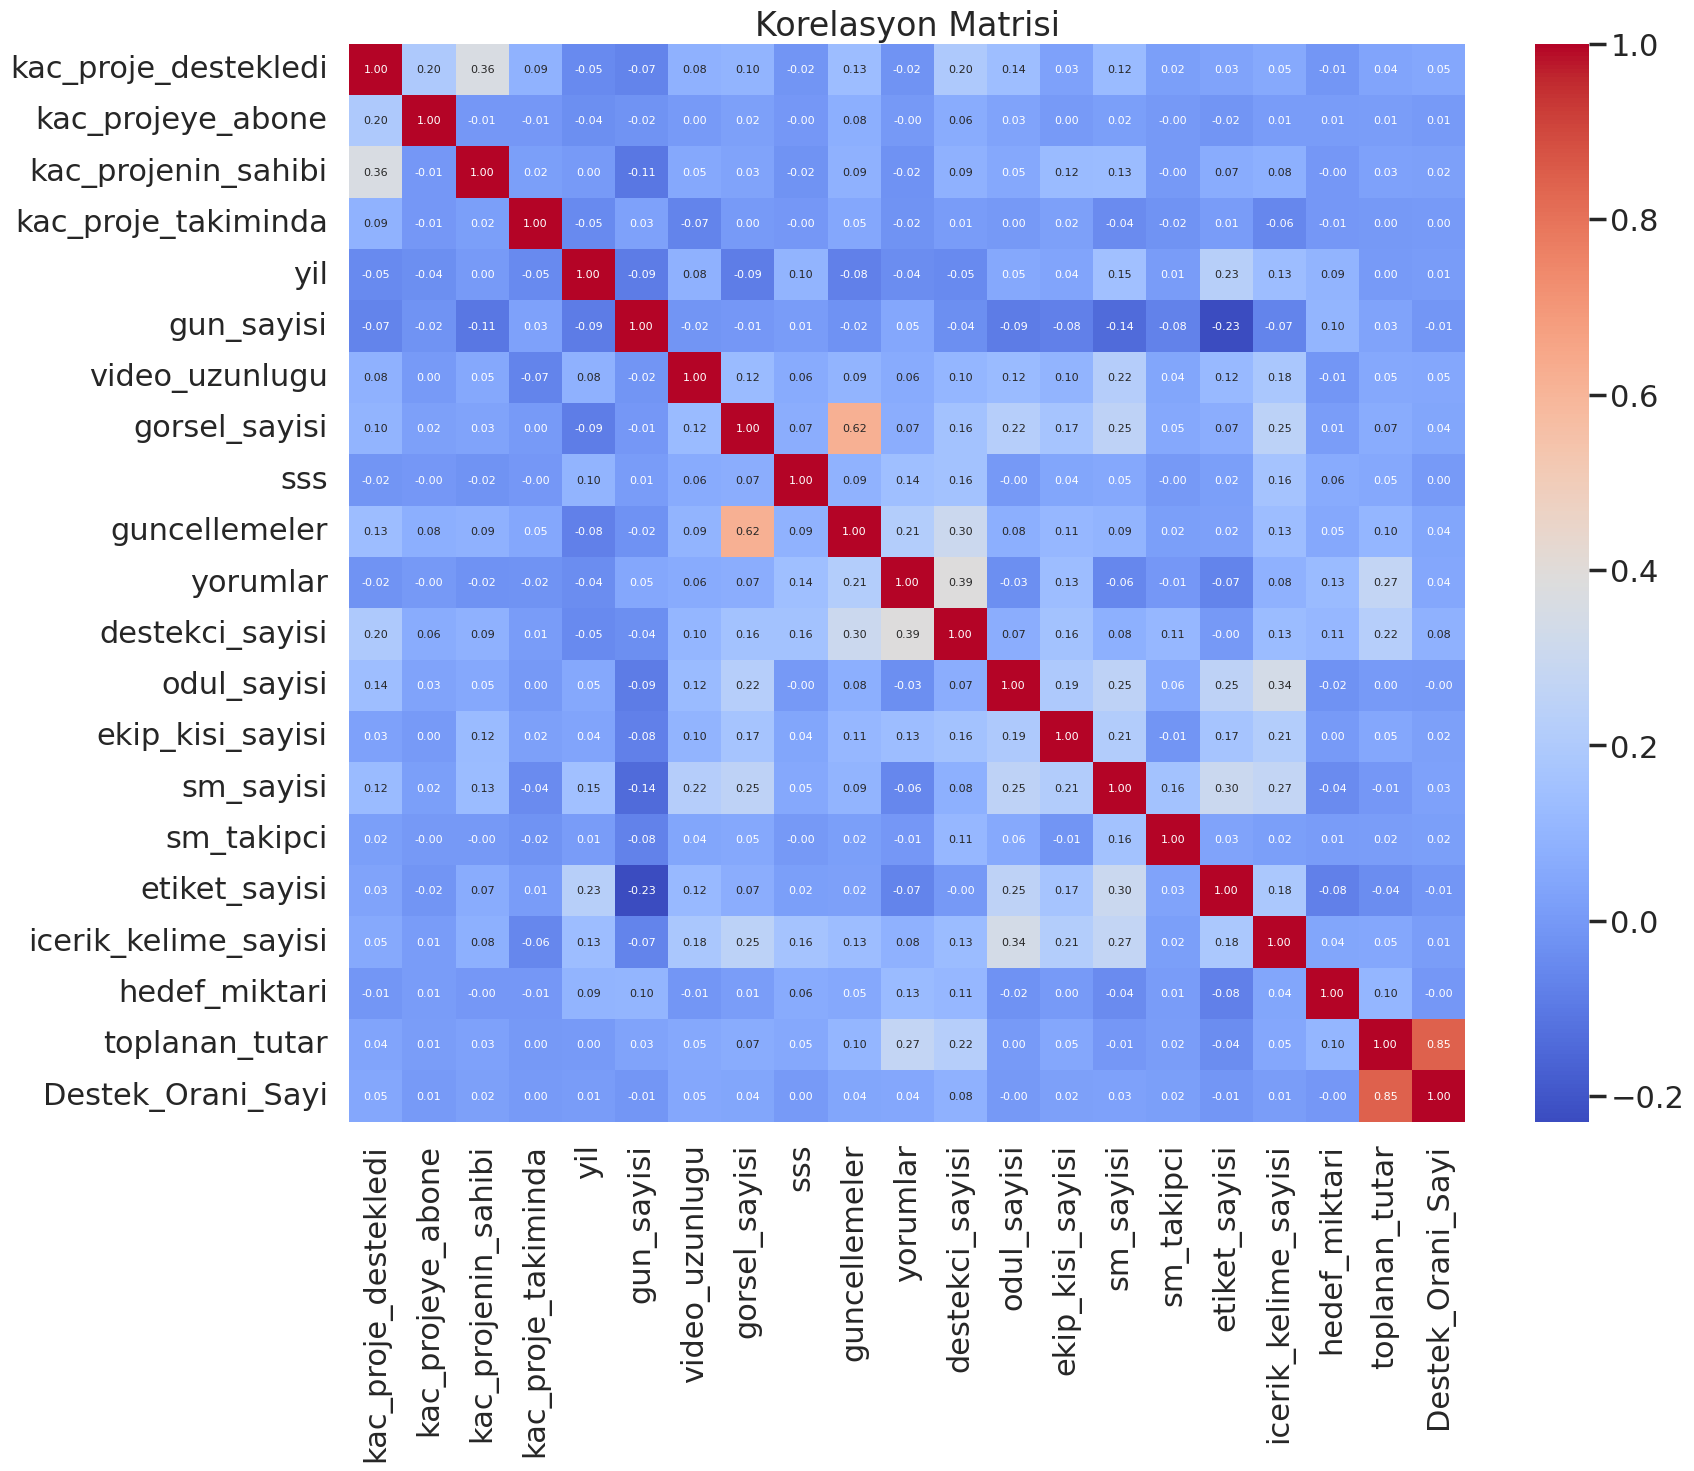

In [8]:
numeric_cols = df.drop(columns=["id"]).select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(18, 14
                    ))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size":8})
plt.title("Korelasyon Matrisi")
plt.show()


In [9]:
drop_cols = ["id","proje_adi","proje_sahibi","konum","proje_baslama_tarihi",
             "proje_bitis_tarihi","proje_aciklamasi","destek_orani","basari_durumu"]
df_reg = df.drop(columns=drop_cols)

categorical_cols = df_reg.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df_reg, columns=categorical_cols,drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded


,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,yil,gun_sayisi,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,...,bolge_doğu,bolge_ege,bolge_genel,bolge_güneydoğu,bolge_iç anadolu,bolge_karadeniz,bolge_marmara,tanitim_videosu_yok,web_sitesi_yok,sosyal_medya_yok
0,1,0,1,0,2014,62,104,1,0,4,...,0,0,0,0,0,0,1,0,1,0
1,3,0,2,0,2015,60,0,12,0,0,...,0,0,0,0,0,0,1,1,1,0
2,0,0,2,1,2017,60,60,8,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,2019,60,67,6,0,0,...,0,1,0,0,0,0,0,0,0,0
4,2,0,1,0,2019,60,149,5,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1623,0,0,1,0,2017,60,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1
1624,0,0,1,0,2017,60,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1
1625,0,0,1,0,2017,60,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1
1626,0,0,1,0,2017,60,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1


In [10]:
X= df_encoded.drop(columns=["toplanan_tutar","Destek_Orani_Sayi"])
y= df_encoded["toplanan_tutar"]

In [11]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
model=LinearRegression()
model.fit(X_train,y_train)
model_pred =model.predict(X_test)

In [13]:
r2_multi = r2_score(y_test,model_pred)
print("R2 Değeri:",r2_multi)
mae_multi = mean_absolute_error(y_test,model_pred)
print("MAE Değeri:",mae_multi)
mse_multi = mean_squared_error(y_test,model_pred)
print("MSE Değeri:",mse_multi)

R2 Değeri: -0.0027452541962196264
MAE Değeri: 18044.92815454443
MSE Değeri: 22225003654.584423


In [14]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train,X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         toplanan_tutar   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     9.923
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           7.90e-64
Time:                        21:25:48   Log-Likelihood:                -15909.
No. Observations:                1302   AIC:                         3.193e+04
Df Residuals:                    1248   BIC:                         3.221e+04
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                        -1.774e+05   1.09e+06     -0.163      0.870   -2.31e+06    1.95e+06
kac_proje_destekledi           454.2833    783.795      0.580      0.562   -1083.419    1991.985
kac_projeye_abone             3.675e-06   2.24e-05      0.164      0.870   -4.02e-05    4.76e-05
kac_projenin_sahibi           5016.2055   2290.065      2.190      0.029     523.403    9509.008
kac_proje_takiminda           5258.1307   8266.980      0.636      0.525    -1.1e+04    2.15e+04
yil                            153.2800    807.346      0.190      0.849   -1430.625    1737.185
gun_sayisi                      -7.8163    105.209     -0.074      0.941    -214.222     198.589
video_uzunlugu                  -7.7768     14.826     -0.525      0.600     -36.863      21.310
gorsel_sayisi                  253.8566    288.996      0.878      0.380    -313.116     820.829
sss                          -1035.4222    979.118     -1.058      0.290   -2956.320     885.476
guncellemeler                 -933.0012   1015.243     -0.919      0.358   -2924.773    1058.771
yorumlar                      1331.0212    128.544     10.355      0.000    1078.835    1583.207
destekci_sayisi                 88.9996     18.856      4.720      0.000      52.006     125.993
odul_sayisi                   1205.5333    819.708      1.471      0.142    -402.624    2813.691
ekip_kisi_sayisi             -1558.5118    875.468     -1.780      0.075   -3276.064     159.040
sm_sayisi                     3025.3082   2205.394      1.372      0.170   -1301.380    7351.997
sm_takipci                       0.0821      0.104      0.787      0.431      -0.122       0.287
etiket_sayisi                  114.8905    780.144      0.147      0.883   -1415.648    1645.429
icerik_kelime_sayisi            -5.6793      5.441     -1.044      0.297     -16.353       4.994
hedef_miktari                    0.0684      0.022      3.073      0.002       0.025       0.112
platform_adi_buluşum         -5.026e+04   2.15e+04     -2.339      0.019   -9.24e+04   -8100.844
platform_adi_crowdfon        -8.434e+04   1.05e+04     -8.067      0.000   -1.05e+05   -6.38e+04
platform_adi_fonbulucu       -8.321e+04    1.6e+04     -5.193      0.000   -1.15e+05   -5.18e+04
platform_adi_fongogo         -8.221e+04   1.51e+04     -5.449      0.000   -1.12e+05   -5.26e+04
platform_adi_ideanest        -1.138e+05   5.43e+05     -0.210      0.834   -1.18e+06    9.52e+05
kitle_fonlamasi_turu_ödül    -6.358e+04   5.44e+05     -0.117      0.907   -1.13e+06       1e+06
kategori_diğer               -1193.3858   2.12e+04     -0.056      0.955   -4.28e+04    4.04e+04
kategori_eğitim              -1828.0927   2.11e+04     -0.086      0.931   -4.33e+04    3.97e+04
kategori_film-video-fotoğraf   -42.5974    2.1e+04     -0.002      0.998   -

Text(0, 0.5, 'Tahmin Edilen Değerler')

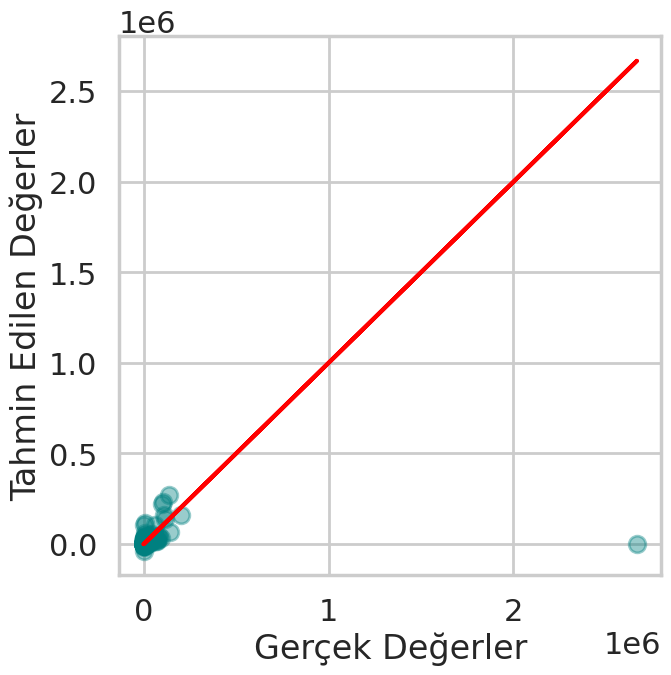

In [15]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,model_pred ,alpha=0.4,color="teal")
plt.plot(y_test,y_test,"r")
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")

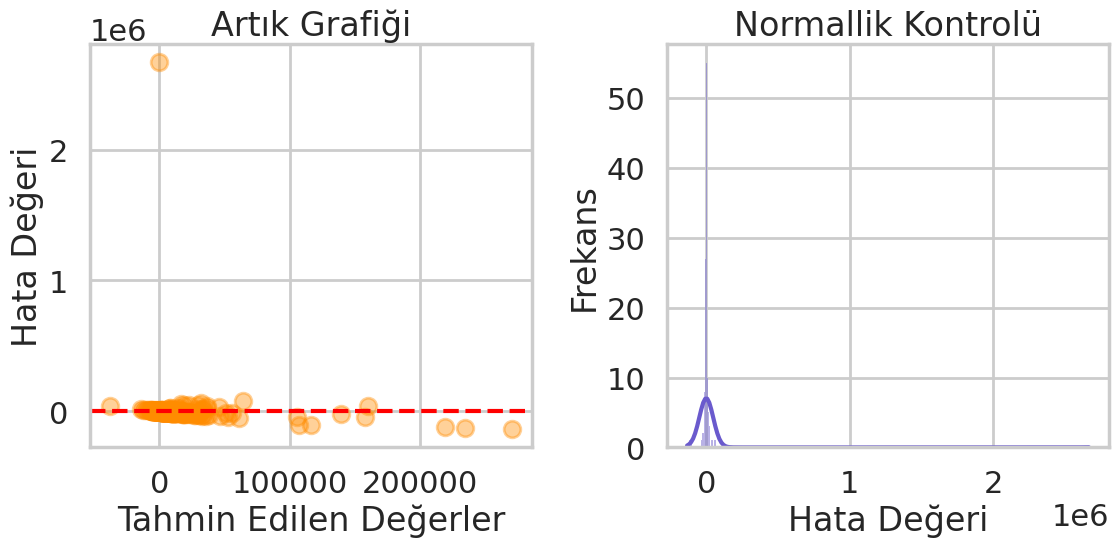

In [16]:
residual =y_test-model_pred
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].scatter(model_pred,residual,alpha=0.4,color="darkorange")
axes[0].axhline(y=0,color="red",linestyle="--")
axes[0].set_xlabel("Tahmin Edilen Değerler")
axes[0].set_ylabel("Hata Değeri")
axes[0].set_title("Artık Grafiği")
sns.histplot(residual,kde=True,ax=axes[1],color="slateblue")
axes[1].set_title("Normallik Kontrolü")
axes[1].set_xlabel("Hata Değeri")
axes[1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()

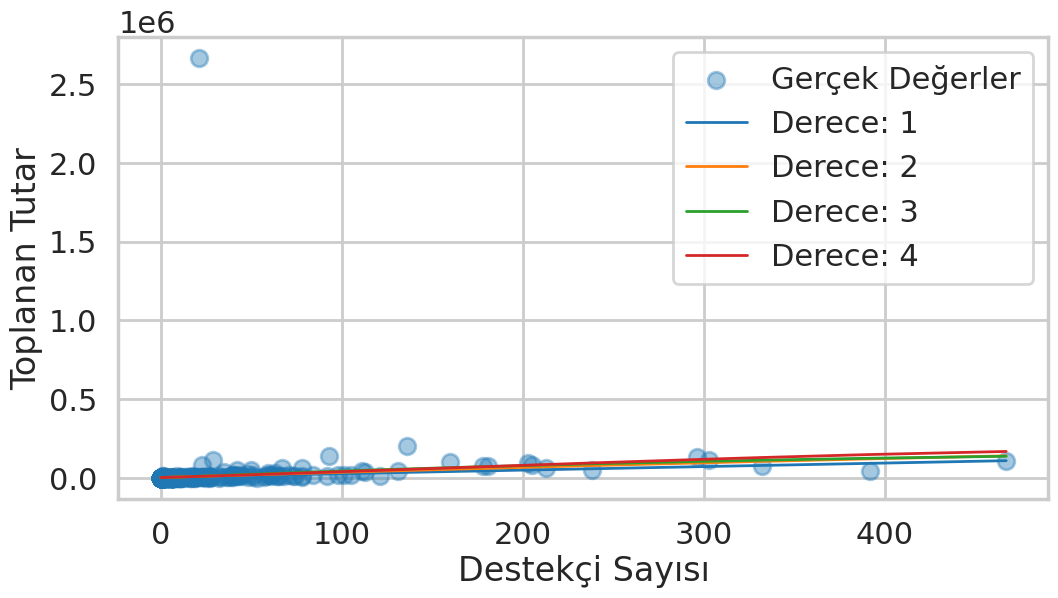

,r2,Rmse
Derece,,
1,0.010275,148109.460516
2,0.011927,147985.853197
3,0.012943,147909.731498
4,0.010868,148065.081335


In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degress =[1,2,3,4]

poly_results= {}

plt.figure(figsize=(12,6))
X_one_train =X_train[['destekci_sayisi']]
X_one_test =X_test[['destekci_sayisi']]
sort_idx =X_one_test['destekci_sayisi'].values.argsort()
x_sorted =X_one_test['destekci_sayisi'].values[sort_idx]
plt.scatter(X_one_test['destekci_sayisi'],y_test,alpha=0.4,color="#1f77b4",label="Gerçek Değerler")
for degree in degress:
    model_poly = make_pipeline(PolynomialFeatures(degree),LinearRegression())
    model_poly.fit(X_one_train,y_train)
    poly_pred = model_poly.predict(X_one_test)
    poly_results[degree]={
        "r2": r2_score(y_test,poly_pred),
        "Rmse" : np.sqrt(mean_squared_error(y_test,poly_pred))
}
    y_line = model_poly.predict(x_sorted.reshape(-1,1))
    plt.plot(x_sorted,y_line,linewidth=2,label=f"Derece: {degree}")
plt.xlabel("Destekçi Sayısı")
plt.ylabel("Toplanan Tutar")
plt.legend()
plt.show()
pd.DataFrame(poly_results).T.rename_axis("Derece")

In [20]:
poly_features = PolynomialFeatures(degree=2)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_multi_model =LinearRegression()
poly_multi_model.fit(X_poly_train,y_train)
poly_multi_pred =poly_multi_model.predict(X_poly_test)

r2_score_poly = r2_score(y_test,poly_multi_pred)
print("R2 Değeri:",r2_score_poly)
mae_poly = mean_absolute_error(y_test,poly_multi_pred)
print("MAE Değeri:",mae_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test,poly_multi_pred))
print("RMSE Değeri:",rmse_poly)

R2 Değeri: -20.4316851248864
MAE Değeri: 125681.75260990922
RMSE Değeri: 689213.4956864868


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,
recall_score,f1_score,classification_report,roc_curve,roc_auc_score)

In [22]:
df = pd.read_csv("/content/turkishCF.csv",sep=";",encoding="utf-8-sig",header=0,names=column_names)

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1628.0,814.500000,470.107435,1.0,407.75,814.5,1221.25,1628.0
kac_proje_destekledi,1628.0,0.429361,2.225029,0.0,0.00,0.0,0.00,31.0
kac_projeye_abone,1628.0,0.000614,0.024784,0.0,0.00,0.0,0.00,1.0
kac_projenin_sahibi,1628.0,1.165848,0.710455,1.0,1.00,1.0,1.00,7.0
kac_proje_takiminda,1628.0,0.052826,0.244744,0.0,0.00,0.0,0.00,4.0
yil,1628.0,2018.042383,2.054583,2011.0,2017.00,2019.0,2020.00,2021.0
gun_sayisi,1628.0,52.004914,15.294526,0.0,45.00,60.0,60.00,118.0
video_uzunlugu,1628.0,67.668305,108.145452,0.0,0.00,46.0,98.25,1651.0
gorsel_sayisi,1628.0,5.036855,7.842166,0.0,1.00,3.0,7.00,221.0
sss,1628.0,0.203317,1.439136,0.0,0.00,0.0,0.00,30.0


In [24]:
df["Basarili"] = (df["basari_durumu"]=="başarılı").astype(int)
df =df.drop(columns=["basari_durumu"])
df["Basarili"].value_counts(normalize=True).rename(index={0:"başarısız",1:"başarılı"})

,proportion
Basarili,
başarısız,0.769042
başarılı,0.230958


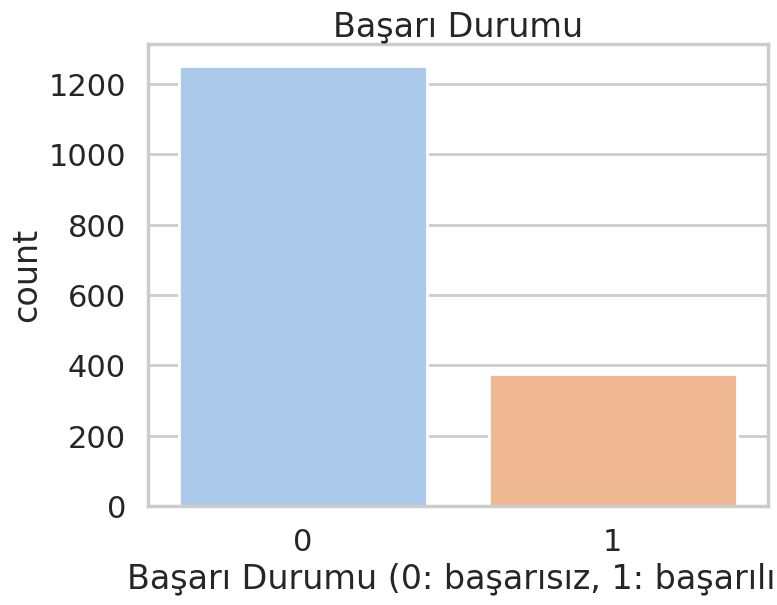

In [25]:
plt.figure(figsize=(8,6))
sns.countplot(x="Basarili",data=df,palette="pastel")

plt.title("Başarı Durumu")
plt.xlabel("Başarı Durumu (0: başarısız, 1: başarılı)")
plt.show()

<Axes: >

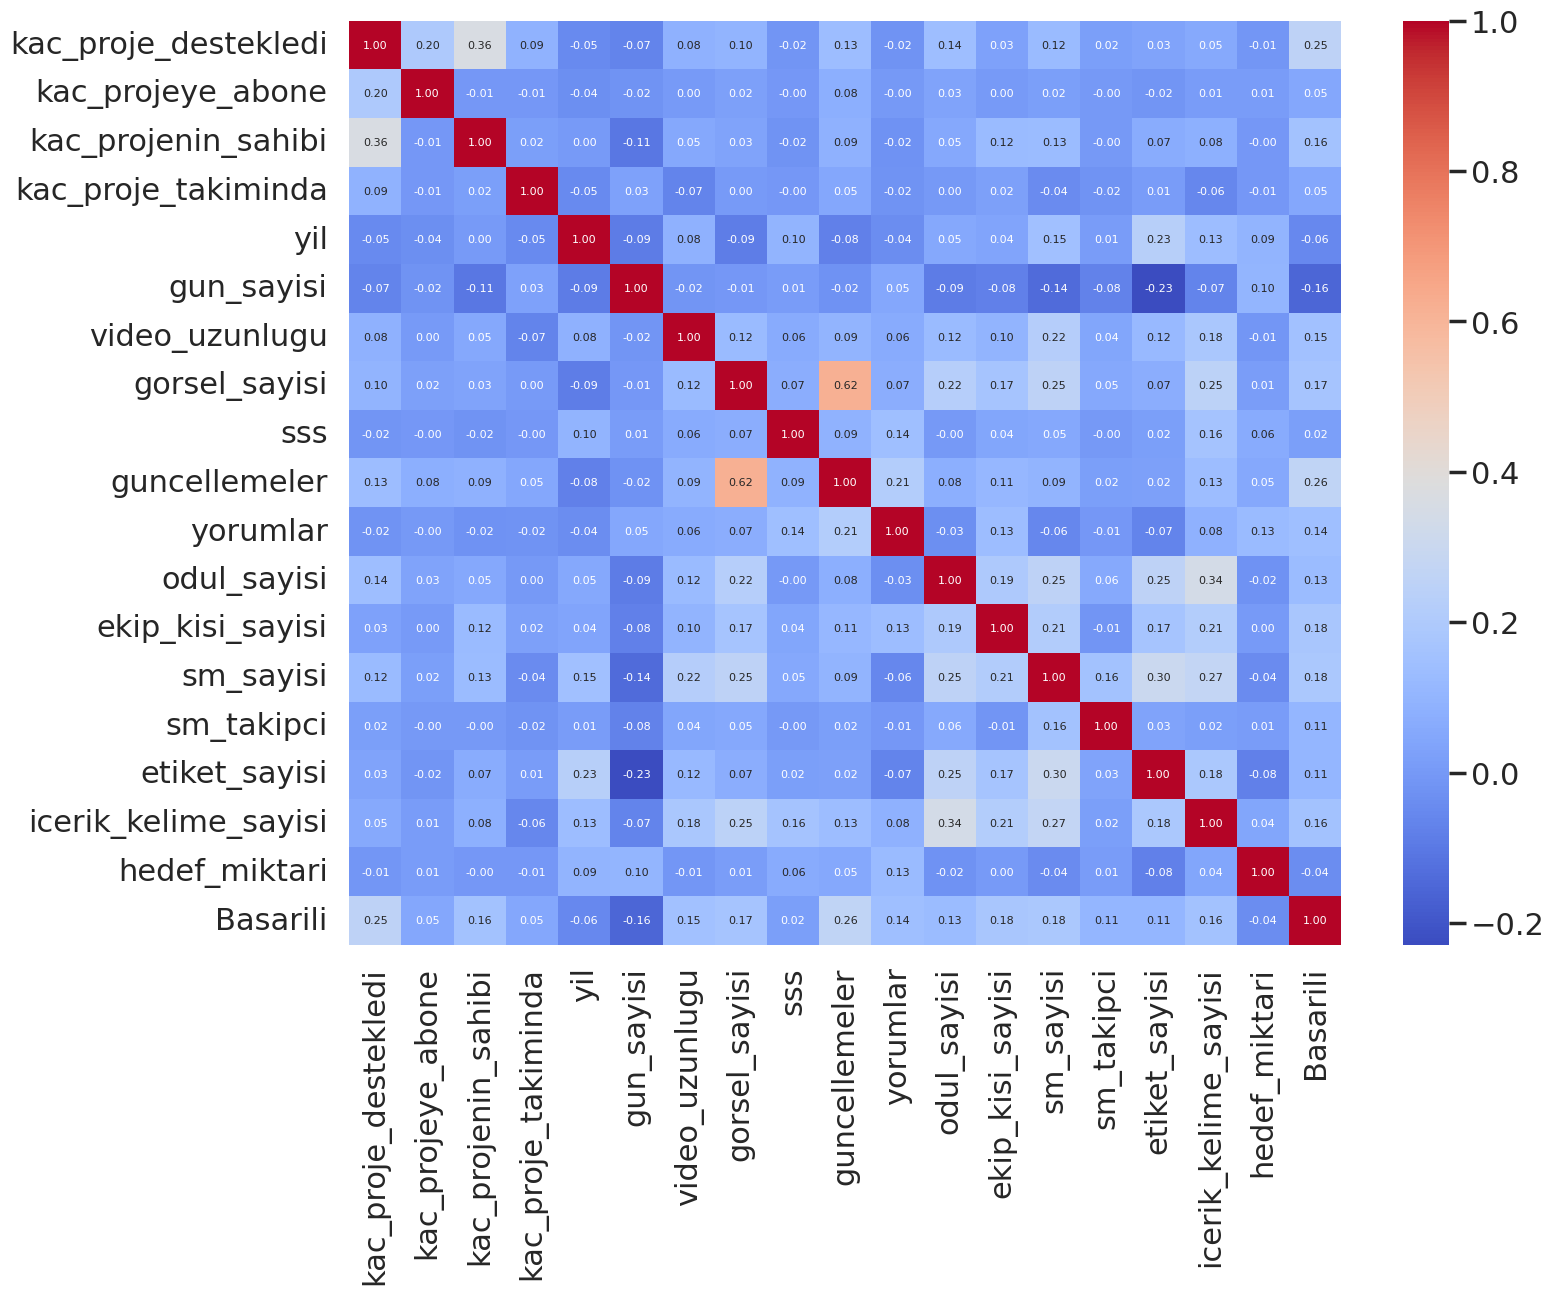

In [26]:
df = df.drop(columns=["id","proje_adi","proje_sahibi","konum","proje_baslama_tarihi",
                      "proje_bitis_tarihi","proje_aciklamasi","destek_orani",
                      "toplanan_tutar","destekci_sayisi"])

numeric_cols=df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",annot_kws={"size":8})

In [27]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,yil,gun_sayisi,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,...,bolge_doğu,bolge_ege,bolge_genel,bolge_güneydoğu,bolge_iç anadolu,bolge_karadeniz,bolge_marmara,tanitim_videosu_yok,web_sitesi_yok,sosyal_medya_yok
0,1,0,1,0,2014,62,104,1,0,4,...,0,0,0,0,0,0,1,0,1,0
1,3,0,2,0,2015,60,0,12,0,0,...,0,0,0,0,0,0,1,1,1,0
2,0,0,2,1,2017,60,60,8,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,2019,60,67,6,0,0,...,0,1,0,0,0,0,0,0,0,0
4,2,0,1,0,2019,60,149,5,0,0,...,0,0,0,0,0,0,1,0,1,0


In [28]:
X=df_encoded.drop(columns=["Basarili"])
y=df_encoded["Basarili"]

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [30]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)
X_train_scaled.head()

,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,yil,gun_sayisi,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,...,bolge_doğu,bolge_ege,bolge_genel,bolge_güneydoğu,bolge_iç anadolu,bolge_karadeniz,bolge_marmara,tanitim_videosu_yok,web_sitesi_yok,sosyal_medya_yok
1103,-0.196527,-0.027724,-0.241605,-0.216574,0.469560,0.519217,-0.197744,-0.382059,-0.137722,-0.208155,...,-0.111542,-0.294638,3.934592,-0.178033,-0.333049,-0.195646,-0.811541,-0.837831,0.595683,-0.949068
993,-0.196527,-0.027724,-0.241605,-0.216574,0.469560,0.519217,-0.061918,-0.262309,-0.137722,-0.208155,...,-0.111542,3.393999,-0.254156,-0.178033,-0.333049,-0.195646,-0.811541,-0.837831,-1.678744,1.053665
1109,-0.196527,-0.027724,-0.241605,-0.216574,-0.024275,0.519217,0.399890,0.695690,-0.137722,-0.208155,...,-0.111542,-0.294638,-0.254156,5.616939,-0.333049,-0.195646,-0.811541,-0.837831,-1.678744,-0.949068
256,-0.196527,-0.027724,-0.241605,-0.216574,0.963395,-1.402207,-0.623332,-0.382059,-0.137722,0.177911,...,8.965211,-0.294638,-0.254156,-0.178033,-0.333049,-0.195646,-0.811541,1.193558,-1.678744,1.053665
122,-0.196527,-0.027724,-0.241605,-0.216574,0.963395,2.312546,-0.623332,-0.382059,-0.137722,-0.208155,...,-0.111542,-0.294638,-0.254156,-0.178033,-0.333049,-0.195646,1.232224,1.193558,0.595683,1.053665


In [31]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_proba =log_reg.predict_proba(X_test_scaled)[:,1]
y_pred =log_reg.predict(X_test_scaled)

results_preview =pd.DataFrame({
    "Gerçek:": y_test.values[:10],
    "Tahmin:": y_pred[:10],
    "Olasılık:": y_proba[:10].round(2)
})
results_preview

,Gerçek:,Tahmin:,Olasılık:
0,1,1,0.99
1,1,0,0.05
2,0,0,0.06
3,0,0,0.01
4,0,0,0.01
5,0,0,0.03
6,0,0,0.03
7,0,0,0.05
8,0,0,0.04
9,0,0,0.09


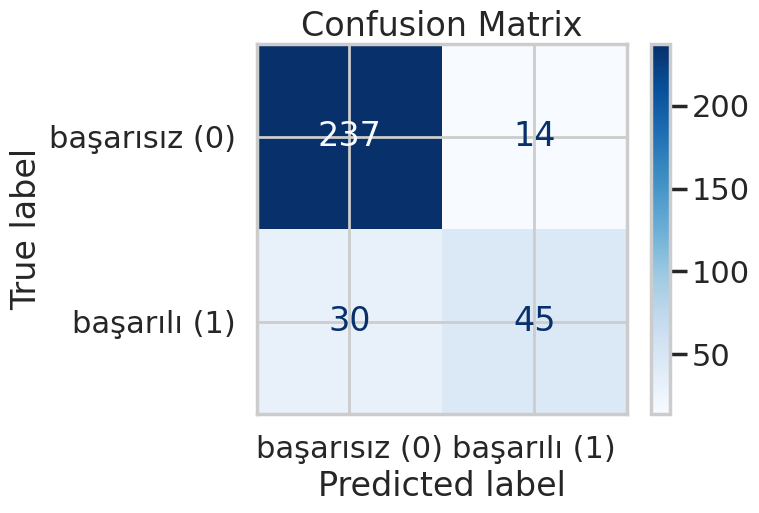

In [35]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["başarısız (0)", "başarılı (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [36]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)


print(classification_report(y_test,y_pred))

Accuracy: 0.8650306748466258
Precision: 0.7627118644067796
Recall: 0.6
F1 Score: 0.6716417910447762
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       251
           1       0.76      0.60      0.67        75

    accuracy                           0.87       326
   macro avg       0.83      0.77      0.79       326
weighted avg       0.86      0.87      0.86       326



In [41]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [42]:
svm_linear = SVC(kernel="linear",C=1.0,probability=True ,random_state=42)
svm_linear.fit(X_train_scaled,y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
y_proba_linear = svm_linear.predict_proba(X_test_scaled)[:,1]

print(f"toplam destek vektörü sayısı: {svm_linear.n_support_.sum()}")
print(f"support_vectors_: {svm_linear.support_vectors_.shape}")

toplam destek vektörü sayısı: 414
support_vectors_: (414, 54)


In [43]:

acc_svm = accuracy_score(y_test,y_pred_linear)
prec_svm = precision_score(y_test,y_pred_linear)
rec_svm = recall_score(y_test,y_pred_linear)
f1_svm = f1_score(y_test,y_pred_linear)

print("Accuracy:",acc_svm)
print("Precision:",prec_svm)
print("Recall:",rec_svm)
print("F1 Score:",f1_svm)
print(classification_report(y_test,y_pred_linear))

Accuracy: 0.8496932515337423
Precision: 0.7321428571428571
Recall: 0.5466666666666666
F1 Score: 0.6259541984732825
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       251
           1       0.73      0.55      0.63        75

    accuracy                           0.85       326
   macro avg       0.80      0.74      0.77       326
weighted avg       0.84      0.85      0.84       326



In [44]:

svm_rbf = SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42)
svm_rbf.fit(X_train_scaled,y_train)

SVC(probability=True, random_state=42)

In [45]:

y_pred_rbf=svm_rbf.predict(X_test_scaled)
y_proba_rbf=svm_rbf.predict_proba(X_test_scaled)[:,1]

In [46]:

acc_svm_rbf = accuracy_score(y_test,y_pred_rbf)
prec_svm_rbf = precision_score(y_test,y_pred_rbf)
rec_svm_rbf = recall_score(y_test,y_pred_rbf)
f1_svm_rbf = f1_score(y_test,y_pred_rbf)
auc = roc_auc_score(y_test,y_proba_rbf)

In [47]:
print("Accuracy:",acc_svm_rbf)
print("Precision:",prec_svm_rbf)
print("Recall:",rec_svm_rbf)
print("F1 Score:",f1_svm_rbf)
print("AUC:",auc)

Accuracy: 0.8619631901840491
Precision: 0.8125
Recall: 0.52
F1 Score: 0.6341463414634146
AUC: 0.8828154050464808


In [48]:

from sklearn.model_selection import GridSearchCV,cross_val_score

param_grid = {
    "C":[0.1,1,10,100],
    "gamma":[1,0.1,0.01,0.001],
    "kernel":["rbf"]
}

grid_search = GridSearchCV(SVC(probability=True),param_grid,cv=5,scoring="f1",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("En iyi parametreler:",grid_search.best_params_)
print("En iyi skor:",grid_search.best_score_)


En iyi parametreler: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
En iyi skor: 0.6704417862632182


In [49]:
svm_best = grid_search.best_estimator_

y_pred_best = svm_best.predict(X_test_scaled)
y_proba_best = svm_best.predict_proba(X_test_scaled)[:,1]


acc_svm_best = accuracy_score(y_test,y_pred_best)
prec_svm_best = precision_score(y_test,y_pred_best)
rec_svm_best = recall_score(y_test,y_pred_best)
f1_svm_best = f1_score(y_test,y_pred_best)
auc_svm_best = roc_auc_score(y_test,y_proba_best)


print("Accuracy:",acc_svm_best)
print("Precision:",prec_svm_best)
print("Recall:",rec_svm_best)
print("F1 Score:",f1_svm_best)
print("AUC:",auc_svm_best)

Accuracy: 0.8558282208588958
Precision: 0.7413793103448276
Recall: 0.5733333333333334
F1 Score: 0.6466165413533834
AUC: 0.8586985391766269


In [50]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
pca = PCA(n_components=3,random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
np.random.seed(42)
sample_idx =np.random.choice(len(X_train_pca))
sample_point =X_train_pca[sample_idx]

distances = np.sqrt(((X_train_pca-sample_point)**2).sum(axis=1))
k_example=10
nearest_neighbors = distances.argsort()[1:k_example+1]
knn = KNeighborsClassifier(n_neighbors=k_example)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=10)

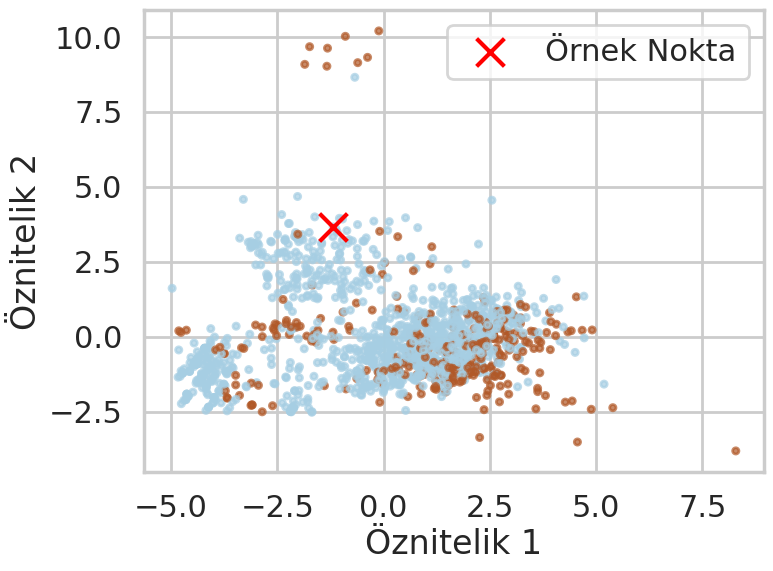

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train,cmap=plt.cm.Paired,alpha=0.70,s=20)
plt.scatter(sample_point[0],sample_point[1],c="red",marker="x",s=400,label="Örnek Nokta")

plt.xlabel("Öznitelik 1")
plt.ylabel("Öznitelik 2")
plt.legend()
plt.show()


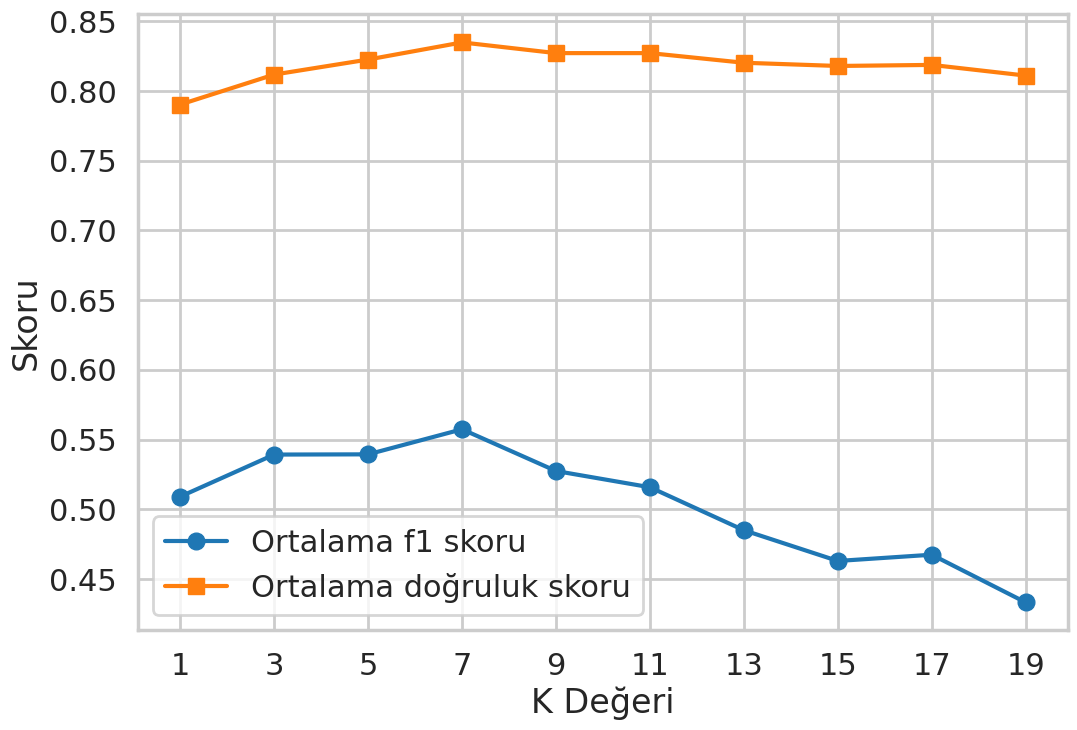

In [52]:

k_values = list(range(1,21,2))
cv_f1_scores=[]
cv_accuracy_scores=[]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    f1_scores = cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring="f1")
    accuracy_scores = cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring="accuracy")
    cv_f1_scores.append(np.mean(f1_scores))
    cv_accuracy_scores.append(np.mean(accuracy_scores))
plt.figure(figsize=(12,8))
plt.plot(k_values,cv_f1_scores,marker="o",label="Ortalama f1 skoru")
plt.plot(k_values,cv_accuracy_scores,marker="s",label="Ortalama doğruluk skoru")
plt.xlabel("K Değeri")
plt.ylabel("Skoru")
plt.legend()
plt.xticks(k_values)
plt.show()


In [53]:
param_grid = {
    "n_neighbors":list(range(1,21,2)),
    "weights":["uniform","distance"],
    "p":[1,2]
}

grid_search = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring="f1",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("En iyi parametreler:",grid_search.best_params_)
print("En iyi skor:",grid_search.best_score_)


En iyi parametreler: {'n_neighbors': 7, 'p': 2, 'weights': 'distance'}
En iyi skor: 0.5732790421899333


In [54]:

knn_best =grid_search.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)
y_proba_knn = knn_best.predict_proba(X_test_scaled)[:,1]

acc_knn = accuracy_score(y_test,y_pred_knn)
prec_knn = precision_score(y_test,y_pred_knn)
rec_knn = recall_score(y_test,y_pred_knn)
f1_knn = f1_score(y_test,y_pred_knn)
auc_knn = roc_auc_score(y_test,y_proba_knn)

print("Accuracy:",acc_knn)
print("Precision:",prec_knn)
print("Recall:",rec_knn)
print("F1 Score:",f1_knn)
print("AUC:",auc_knn)

Accuracy: 0.8374233128834356
Precision: 0.775
Recall: 0.41333333333333333
F1 Score: 0.5391304347826087
AUC: 0.8047808764940239


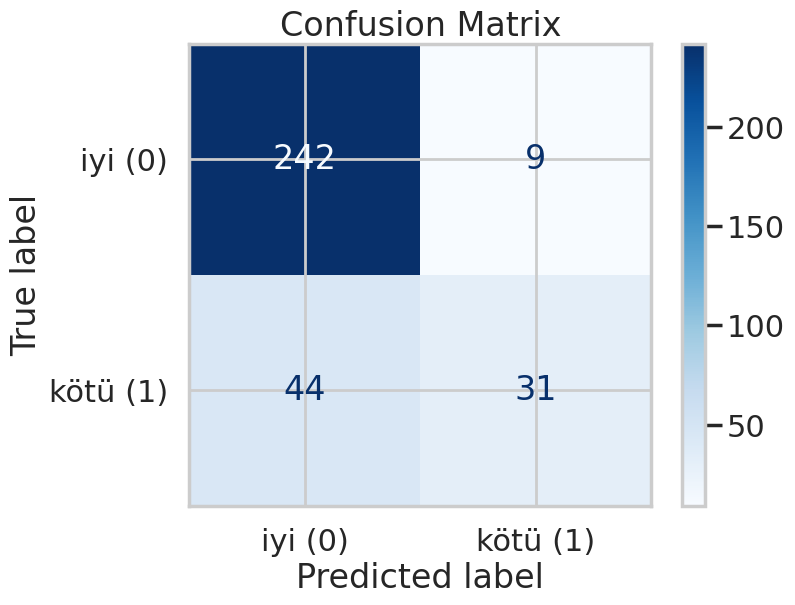

In [55]:
cm = confusion_matrix(y_test,y_pred_knn)
fig,ax =plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["iyi (0)","kötü (1)"])
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [56]:
# Karşılaştırma için lojistik regresyon ve SVM modellerini de aynı veriyle eğitelim
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm = svm_rbf.predict(X_test_scaled)
y_proba_svm = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# Tüm modellerin metriklerini tek bir tabloda topla
comparison_df = pd.DataFrame({
    "Model": ["Lojistik Regresyon", "SVM (RBF)", f"KNN (k={grid_search.best_params_['n_neighbors']})"],
    "Doğruluk": [
        accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_svm), acc_knn
    ],
    "Kesinlik": [
        precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_svm), prec_knn
    ],
    "Duyarlılık": [
        recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_svm), rec_knn
    ],
    "F1": [
        f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_svm), f1_knn
    ],
    "AUC": [
        roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_svm), auc_knn
    ]
})

comparison_df.round(3)

,Model,Doğruluk,Kesinlik,Duyarlılık,F1,AUC
0,Lojistik Regresyon,0.865,0.763,0.600,0.672,0.890
1,SVM (RBF),0.862,0.812,0.520,0.634,0.883
2,KNN (k=7),0.837,0.775,0.413,0.539,0.805
